# 05 — Final Evaluation and Deployment Decision

> **Research question:** Does the cleaned `finetuning-v6` LoRA configuration outperform prompt engineering alone strongly enough to become AXION's final production baseline?

The previous notebooks established the complete experimental sequence:

1. Notebook 01 measured the raw base model.
2. Notebook 02 optimized the routing system prompt.
3. Notebook 03 audited and cleaned the supervised dataset.
4. Notebook 04 trained `finetuning-v6` and selected checkpoint 450.
5. This notebook compares the final configurations and makes the deployment decision.

The comparison covers:

- single-step routing;
- multi-step execution;
- incremental gains;
- latency where directly available;
- the practical contribution of fine-tuning;
- the final production recommendation.

The benchmark used for `finetuning-v6` has zero exact normalized overlap with
the cleaned fine-tuning corpus.


## Executive Summary

Notebook 04 established that checkpoint **450** is the correct fine-tuned model
to retain:

- minimum validation loss: **0.542**;
- strongest multi-step accuracy among checkpoints 450, 650 and 850;
- strongest tool ordering and loop completion among the tested checkpoints.

The final comparison produces a more nuanced result:

- prompt engineering created almost all of the usable routing behavior;
- checkpoint 450 slightly improves category and parameter accuracy;
- checkpoint 450 does not improve strict single-step accuracy;
- checkpoint 450 degrades multi-step ordering and loop completion.

Therefore:

- **checkpoint 450 is the best fine-tuned checkpoint**;
- **the prompt-engineered base model remains the strongest overall deployment
  baseline** on the current clean benchmark;
- the LoRA experiment remains valuable because it reveals where supervised
  adaptation helps and where it damages agentic control.

All fine-tuned metrics in this notebook are aligned with the canonical
`CHECKPOINT_RESULTS` dictionary from Notebook 04.


## 1. Imports and Display Configuration


In [1]:
import platform
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

pd.set_option("display.max_colwidth", 120)

plt.rcParams.update({
    "figure.dpi": 130,
    "figure.figsize": (9, 5),
    "axes.titleweight": "bold",
    "axes.titlesize": 14,
    "axes.labelsize": 11,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "legend.frameon": False,
})

print(f"Python: {sys.version.split()[0]}")
print(f"Platform: {platform.platform()}")


Python: 3.12.13
Platform: macOS-26.2-arm64-arm-64bit


## 2. Evaluation Protocol

Two suites are used.

### Single-step benchmark

- 320 prompts;
- category, tool and parameter comparison;
- strict pass requires the complete expected action to be correct;
- application success estimates whether the generated action would behave as
  intended at runtime.

### Multi-step benchmark

- 50 scenarios;
- step accuracy;
- tool-order accuracy;
- avoidance of unnecessary tools;
- final-response accuracy;
- loop-completion accuracy;
- average scenario latency.

Only metrics directly present in the retained raw benchmark outputs are
compared. Missing values are not reconstructed or inferred.


## 3. Canonical Evaluation Data


In [2]:
RAW_BASELINE = {
    # Transcribed from the raw outputs produced by benchmark.py
    # and benchmark_multistep.py.
    "configuration": "Raw base model",
    "single_step": {
        "category_accuracy": 0,
        "tool_accuracy": 0,
        "parameter_accuracy": 4,
        "strict_pass_rate": 0,
        "application_success": 0,
        "average_latency_seconds": 2.08,
    },
    "multi_step": {
        "step_accuracy": 45,
        "tool_order_accuracy": 42,
        "no_extra_tools_accuracy": 42,
        "final_accuracy": 42,
        "loop_completion_accuracy": 42,
        "average_latency_seconds": 3.00,
    },
}

PROMPT_ENGINEERED_BASE = {
    # Transcribed from the raw outputs produced by benchmark.py
    # and benchmark_multistep.py.
    "configuration": "Prompt-engineered base",
    "prompt_tokens": 2469,
    "single_step": {
        "category_accuracy": 93,
        "tool_accuracy": 92,
        "parameter_accuracy": 92,
        "strict_pass_rate": 89,
        "application_success": 91,
        "average_latency_seconds": 0.93,
    },
    "multi_step": {
        "step_accuracy": 98,
        "tool_order_accuracy": 98,
        "no_extra_tools_accuracy": 98,
        "final_accuracy": 98,
        "loop_completion_accuracy": 98,
        "average_latency_seconds": 1.48,
    },
}

FINETUNED_V6_450 = {
    # Copied from CHECKPOINT_RESULTS[450] in Notebook 04.
    # Transcribed there from benchmark.py and benchmark_multistep.py.
    "configuration": "Fine-tuned v6 — checkpoint 450",
    "checkpoint": 450,
    "validation_loss": 0.542,
    "single_step": {
        "category_accuracy": 94,
        "tool_accuracy": 92,
        "parameter_accuracy": 93,
        "strict_pass_rate": 89,
        "application_success": 89,
    },
    "multi_step": {
        "step_accuracy": 92,
        "tool_order_accuracy": 86,
        "no_extra_tools_accuracy": 86,
        "final_accuracy": 98,
        "loop_completion_accuracy": 86,
        "average_latency_seconds": 1.14,
    },
}

EVALUATION_METADATA = {
    "single_step_examples": 320,
    "multi_step_scenarios": 50,
    "train_benchmark_exact_overlap": 0,
    "selected_checkpoint": 450,
    "selected_validation_loss": 0.542,
}

assert FINETUNED_V6_450["checkpoint"] == EVALUATION_METADATA["selected_checkpoint"]
assert np.isclose(
    FINETUNED_V6_450["validation_loss"],
    EVALUATION_METADATA["selected_validation_loss"],
)

print("Canonical final-evaluation data loaded.")


Canonical final-evaluation data loaded.


### Alignment with Notebook 04

The fine-tuned values above reproduce the checkpoint selected in Notebook 04:

| Checkpoint | Validation loss | Strict | Multi-step | Tool order | Loop completion |
|---:|---:|---:|---:|---:|---:|
| **450** | **0.542** | 89% | **92%** | **86%** | **86%** |
| 650 | 0.545 | 90% | 86% | 72% | 72% |
| 850 | 0.567 | 91% | 85% | 70% | 70% |

Checkpoint 850 is not the final model. It only achieved the highest strict
single-step score among the three tested checkpoints, while producing the
weakest multi-step ordering and loop completion.


## 4. Single-Step Routing Comparison


In [3]:
single_step = pd.DataFrame({
    "Configuration": [
        RAW_BASELINE["configuration"],
        PROMPT_ENGINEERED_BASE["configuration"],
        FINETUNED_V6_450["configuration"],
    ],
    "Category accuracy (%)": [
        RAW_BASELINE["single_step"]["category_accuracy"],
        PROMPT_ENGINEERED_BASE["single_step"]["category_accuracy"],
        FINETUNED_V6_450["single_step"]["category_accuracy"],
    ],
    "Tool accuracy (%)": [
        RAW_BASELINE["single_step"]["tool_accuracy"],
        PROMPT_ENGINEERED_BASE["single_step"]["tool_accuracy"],
        FINETUNED_V6_450["single_step"]["tool_accuracy"],
    ],
    "Parameter accuracy (%)": [
        RAW_BASELINE["single_step"]["parameter_accuracy"],
        PROMPT_ENGINEERED_BASE["single_step"]["parameter_accuracy"],
        FINETUNED_V6_450["single_step"]["parameter_accuracy"],
    ],
    "Strict pass rate (%)": [
        RAW_BASELINE["single_step"]["strict_pass_rate"],
        PROMPT_ENGINEERED_BASE["single_step"]["strict_pass_rate"],
        FINETUNED_V6_450["single_step"]["strict_pass_rate"],
    ],
    "Application success (%)": [
        RAW_BASELINE["single_step"]["application_success"],
        PROMPT_ENGINEERED_BASE["single_step"]["application_success"],
        FINETUNED_V6_450["single_step"]["application_success"],
    ],
})

display(single_step.style.hide(axis="index"))


Configuration,Category accuracy (%),Tool accuracy (%),Parameter accuracy (%),Strict pass rate (%),Application success (%)
Raw base model,0,0,4,0,0
Prompt-engineered base,93,92,92,89,91
Fine-tuned v6 — checkpoint 450,94,92,93,89,89


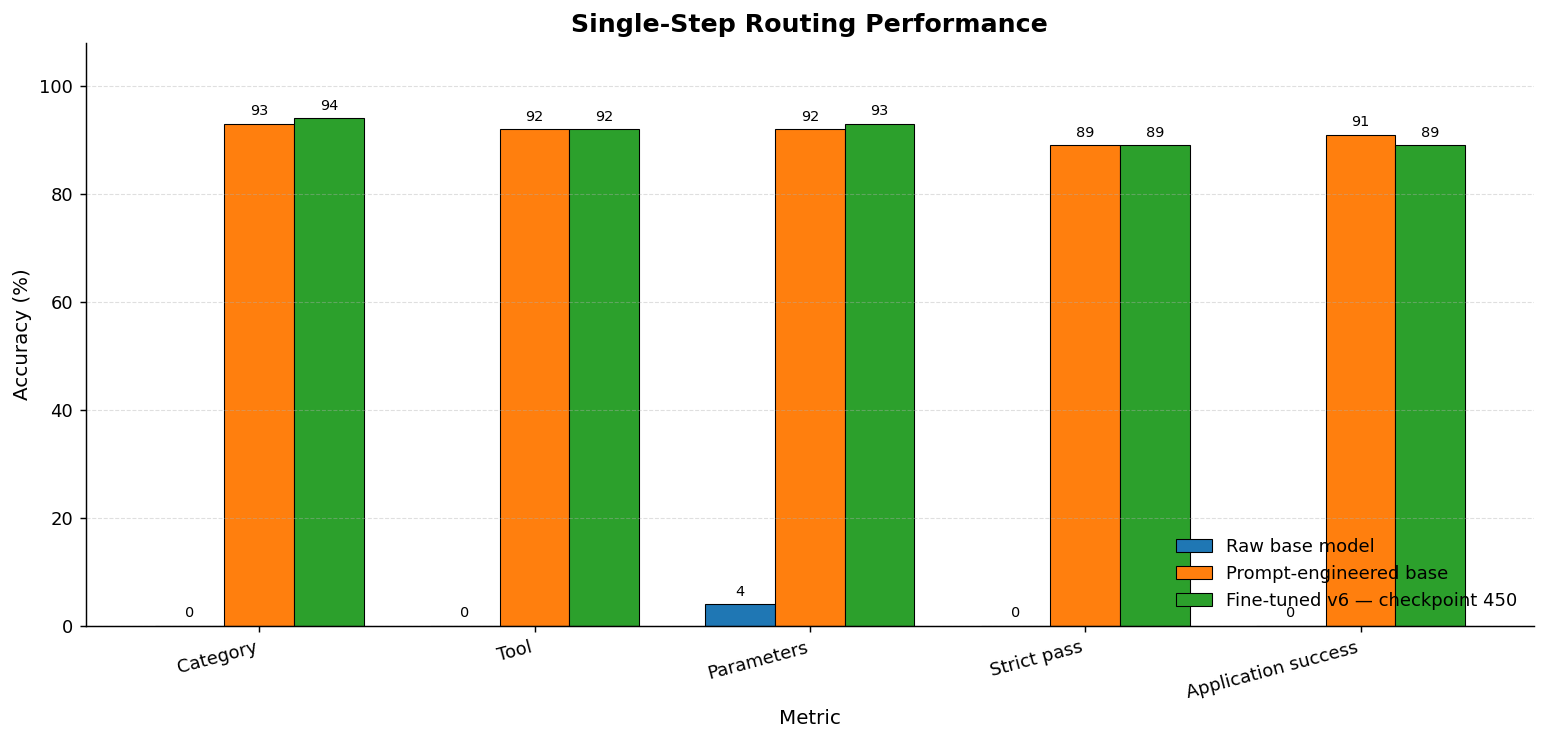

In [4]:
single_metrics = [
    "Category accuracy (%)",
    "Tool accuracy (%)",
    "Parameter accuracy (%)",
    "Strict pass rate (%)",
    "Application success (%)",
]

single_plot = single_step.set_index(
    "Configuration"
)[single_metrics].T

ax = single_plot.plot(
    kind="bar",
    figsize=(12, 5.8),
    width=0.76,
    edgecolor="black",
    linewidth=0.6,
)

for container in ax.containers:
    ax.bar_label(
        container,
        fmt="%.0f",
        padding=3,
        fontsize=8,
    )

ax.set_xlabel("Metric")
ax.set_ylabel("Accuracy (%)")
ax.set_title("Single-Step Routing Performance")
ax.set_ylim(0, 108)
ax.set_xticklabels([
    "Category",
    "Tool",
    "Parameters",
    "Strict pass",
    "Application success",
], rotation=15, ha="right")
ax.grid(
    axis="y",
    linestyle="--",
    linewidth=0.6,
    alpha=0.4,
)
ax.legend(loc="lower right")

plt.tight_layout()
plt.show()


**Figure 1 — Single-step routing.** Prompt engineering provides the dominant
improvement over the raw model.

Relative to the prompt-engineered base model, checkpoint 450:

- gains 1 point in category accuracy;
- matches tool accuracy;
- gains 1 point in parameter accuracy;
- matches strict pass rate at 89%;
- loses 2 points in application success.

The adapter changes the distribution of remaining errors, but does not improve
the complete strict single-step result.


## 5. Incremental Single-Step Gains


In [5]:
single_indexed = single_step.set_index("Configuration")

single_gain = pd.DataFrame({
    "Metric": single_metrics,
    "Raw → prompt engineered": [
        single_indexed.loc[
            PROMPT_ENGINEERED_BASE["configuration"],
            metric,
        ]
        - single_indexed.loc[
            RAW_BASELINE["configuration"],
            metric,
        ]
        for metric in single_metrics
    ],
    "Prompt engineered → fine-tuned": [
        single_indexed.loc[
            FINETUNED_V6_450["configuration"],
            metric,
        ]
        - single_indexed.loc[
            PROMPT_ENGINEERED_BASE["configuration"],
            metric,
        ]
        for metric in single_metrics
    ],
})

display(
    single_gain.style
    .format({
        "Raw → prompt engineered": "{:+.0f} points",
        "Prompt engineered → fine-tuned": "{:+.0f} points",
    })
    .hide(axis="index")
)


Metric,Raw → prompt engineered,Prompt engineered → fine-tuned
Category accuracy (%),+93 points,+1 points
Tool accuracy (%),+92 points,+0 points
Parameter accuracy (%),+88 points,+1 points
Strict pass rate (%),+89 points,+0 points
Application success (%),+91 points,-2 points


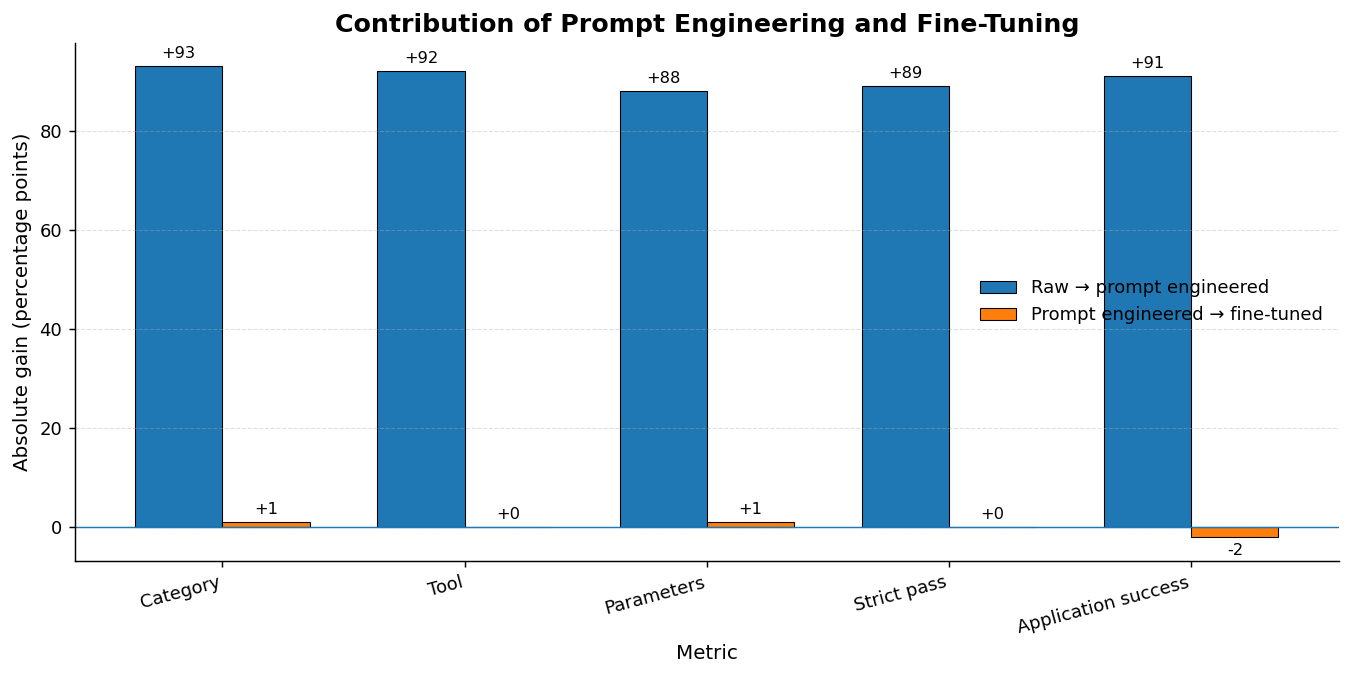

In [6]:
gain_plot = single_gain.set_index("Metric")

ax = gain_plot.plot(
    kind="bar",
    figsize=(10.5, 5.3),
    width=0.72,
    edgecolor="black",
    linewidth=0.6,
)

for container in ax.containers:
    ax.bar_label(
        container,
        fmt="%+.0f",
        padding=3,
        fontsize=9,
    )

ax.axhline(0, linewidth=0.8)
ax.set_xlabel("Metric")
ax.set_ylabel("Absolute gain (percentage points)")
ax.set_title("Contribution of Prompt Engineering and Fine-Tuning")
ax.set_xticklabels([
    "Category",
    "Tool",
    "Parameters",
    "Strict pass",
    "Application success",
], rotation=15, ha="right")
ax.grid(
    axis="y",
    linestyle="--",
    linewidth=0.6,
    alpha=0.4,
)

plt.tight_layout()
plt.show()


**Figure 2 — Incremental gains.** Prompt engineering established almost all of
the usable routing behavior. Fine-tuning contributed only narrow gains in
category and parameter prediction, without improving strict accuracy.

The clean experiment therefore does not support the claim that this LoRA run
outperforms prompt engineering alone for single-step execution.


## 6. Multi-Step Agent Comparison


In [7]:
multi_step = pd.DataFrame({
    "Configuration": [
        RAW_BASELINE["configuration"],
        PROMPT_ENGINEERED_BASE["configuration"],
        FINETUNED_V6_450["configuration"],
    ],
    "Step accuracy (%)": [
        RAW_BASELINE["multi_step"]["step_accuracy"],
        PROMPT_ENGINEERED_BASE["multi_step"]["step_accuracy"],
        FINETUNED_V6_450["multi_step"]["step_accuracy"],
    ],
    "Tool-order accuracy (%)": [
        RAW_BASELINE["multi_step"]["tool_order_accuracy"],
        PROMPT_ENGINEERED_BASE["multi_step"]["tool_order_accuracy"],
        FINETUNED_V6_450["multi_step"]["tool_order_accuracy"],
    ],
    "No-extra-tools accuracy (%)": [
        RAW_BASELINE["multi_step"]["no_extra_tools_accuracy"],
        PROMPT_ENGINEERED_BASE["multi_step"]["no_extra_tools_accuracy"],
        FINETUNED_V6_450["multi_step"]["no_extra_tools_accuracy"],
    ],
    "Final accuracy (%)": [
        RAW_BASELINE["multi_step"]["final_accuracy"],
        PROMPT_ENGINEERED_BASE["multi_step"]["final_accuracy"],
        FINETUNED_V6_450["multi_step"]["final_accuracy"],
    ],
    "Loop-completion accuracy (%)": [
        RAW_BASELINE["multi_step"]["loop_completion_accuracy"],
        PROMPT_ENGINEERED_BASE["multi_step"]["loop_completion_accuracy"],
        FINETUNED_V6_450["multi_step"]["loop_completion_accuracy"],
    ],
})

display(multi_step.style.hide(axis="index"))


Configuration,Step accuracy (%),Tool-order accuracy (%),No-extra-tools accuracy (%),Final accuracy (%),Loop-completion accuracy (%)
Raw base model,45,42,42,42,42
Prompt-engineered base,98,98,98,98,98
Fine-tuned v6 — checkpoint 450,92,86,86,98,86


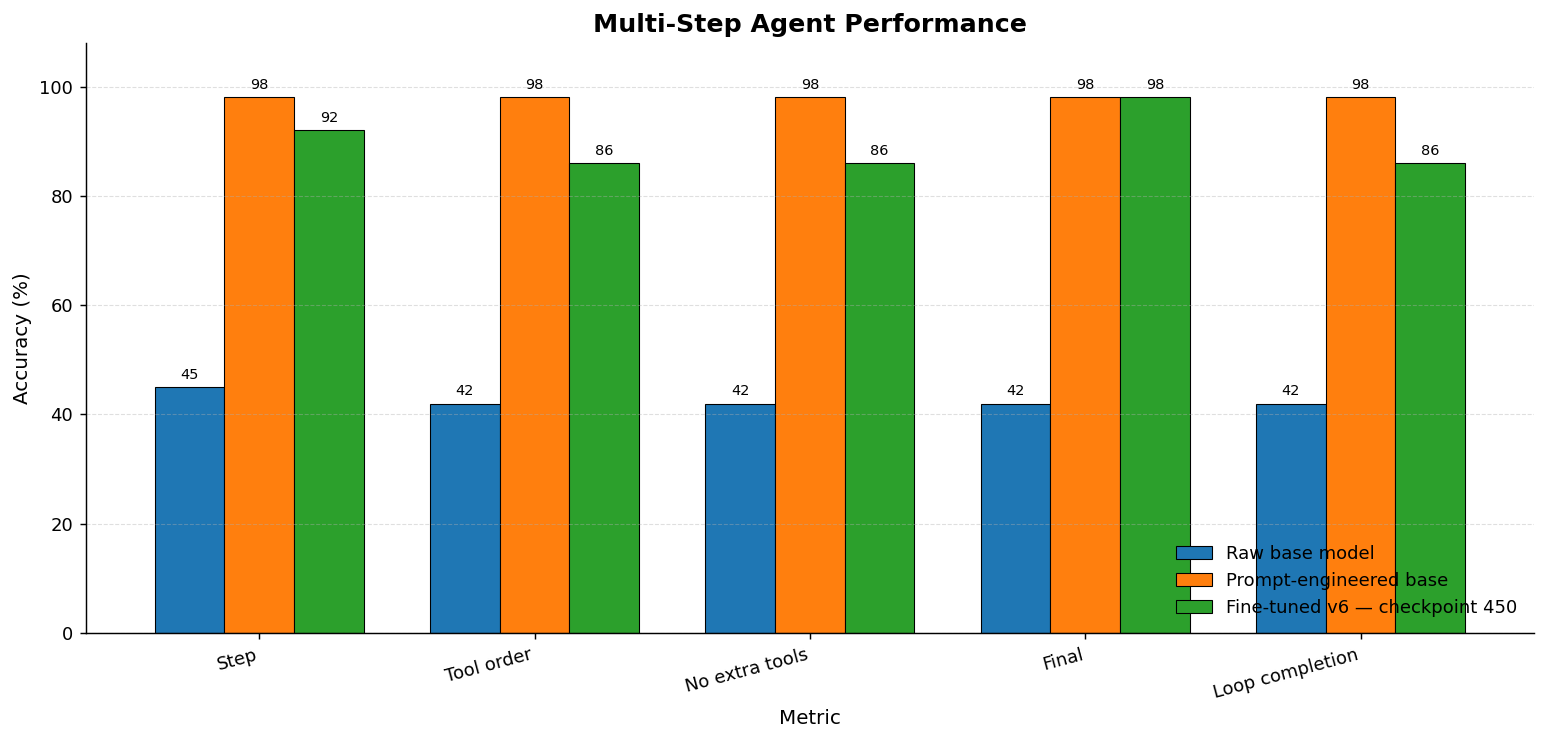

In [8]:
multi_metrics = [
    "Step accuracy (%)",
    "Tool-order accuracy (%)",
    "No-extra-tools accuracy (%)",
    "Final accuracy (%)",
    "Loop-completion accuracy (%)",
]

multi_plot = multi_step.set_index(
    "Configuration"
)[multi_metrics].T

ax = multi_plot.plot(
    kind="bar",
    figsize=(12, 5.8),
    width=0.76,
    edgecolor="black",
    linewidth=0.6,
)

for container in ax.containers:
    ax.bar_label(
        container,
        fmt="%.0f",
        padding=3,
        fontsize=8,
    )

ax.set_xlabel("Metric")
ax.set_ylabel("Accuracy (%)")
ax.set_title("Multi-Step Agent Performance")
ax.set_ylim(0, 108)
ax.set_xticklabels([
    "Step",
    "Tool order",
    "No extra tools",
    "Final",
    "Loop completion",
], rotation=15, ha="right")
ax.grid(
    axis="y",
    linestyle="--",
    linewidth=0.6,
    alpha=0.4,
)
ax.legend(loc="lower right")

plt.tight_layout()
plt.show()


**Figure 3 — Multi-step execution.** The prompt-engineered base model is the
clear winner on agentic control.

Compared with the prompt-engineered base, checkpoint 450:

- loses 6 points in step accuracy;
- loses 12 points in tool ordering;
- loses 12 points in avoiding unnecessary tools;
- matches final-response accuracy at 98%;
- loses 12 points in loop completion.

Checkpoint 450 often reaches the correct final response, but follows a less
reliable execution path. For an agent that invokes real tools, path correctness
is a production requirement rather than a secondary metric.


## 7. Net Behavioral Effect of Fine-Tuning


In [9]:
fine_tuning_delta = pd.DataFrame({
    "Metric": [
        "Category accuracy",
        "Tool accuracy",
        "Parameter accuracy",
        "Strict pass rate",
        "Application success",
        "Multi-step accuracy",
        "Tool-order accuracy",
        "No-extra-tools accuracy",
        "Final accuracy",
        "Loop-completion accuracy",
    ],
    "Change (points)": [
        FINETUNED_V6_450["single_step"]["category_accuracy"]
        - PROMPT_ENGINEERED_BASE["single_step"]["category_accuracy"],

        FINETUNED_V6_450["single_step"]["tool_accuracy"]
        - PROMPT_ENGINEERED_BASE["single_step"]["tool_accuracy"],

        FINETUNED_V6_450["single_step"]["parameter_accuracy"]
        - PROMPT_ENGINEERED_BASE["single_step"]["parameter_accuracy"],

        FINETUNED_V6_450["single_step"]["strict_pass_rate"]
        - PROMPT_ENGINEERED_BASE["single_step"]["strict_pass_rate"],

        FINETUNED_V6_450["single_step"]["application_success"]
        - PROMPT_ENGINEERED_BASE["single_step"]["application_success"],

        FINETUNED_V6_450["multi_step"]["step_accuracy"]
        - PROMPT_ENGINEERED_BASE["multi_step"]["step_accuracy"],

        FINETUNED_V6_450["multi_step"]["tool_order_accuracy"]
        - PROMPT_ENGINEERED_BASE["multi_step"]["tool_order_accuracy"],

        FINETUNED_V6_450["multi_step"]["no_extra_tools_accuracy"]
        - PROMPT_ENGINEERED_BASE["multi_step"]["no_extra_tools_accuracy"],

        FINETUNED_V6_450["multi_step"]["final_accuracy"]
        - PROMPT_ENGINEERED_BASE["multi_step"]["final_accuracy"],

        FINETUNED_V6_450["multi_step"]["loop_completion_accuracy"]
        - PROMPT_ENGINEERED_BASE["multi_step"]["loop_completion_accuracy"],
    ],
})

display(
    fine_tuning_delta.style
    .format({"Change (points)": "{:+.0f}"})
    .hide(axis="index")
)


Metric,Change (points)
Category accuracy,+1
Tool accuracy,+0
Parameter accuracy,+1
Strict pass rate,+0
Application success,-2
Multi-step accuracy,-6
Tool-order accuracy,-12
No-extra-tools accuracy,-12
Final accuracy,+0
Loop-completion accuracy,-12


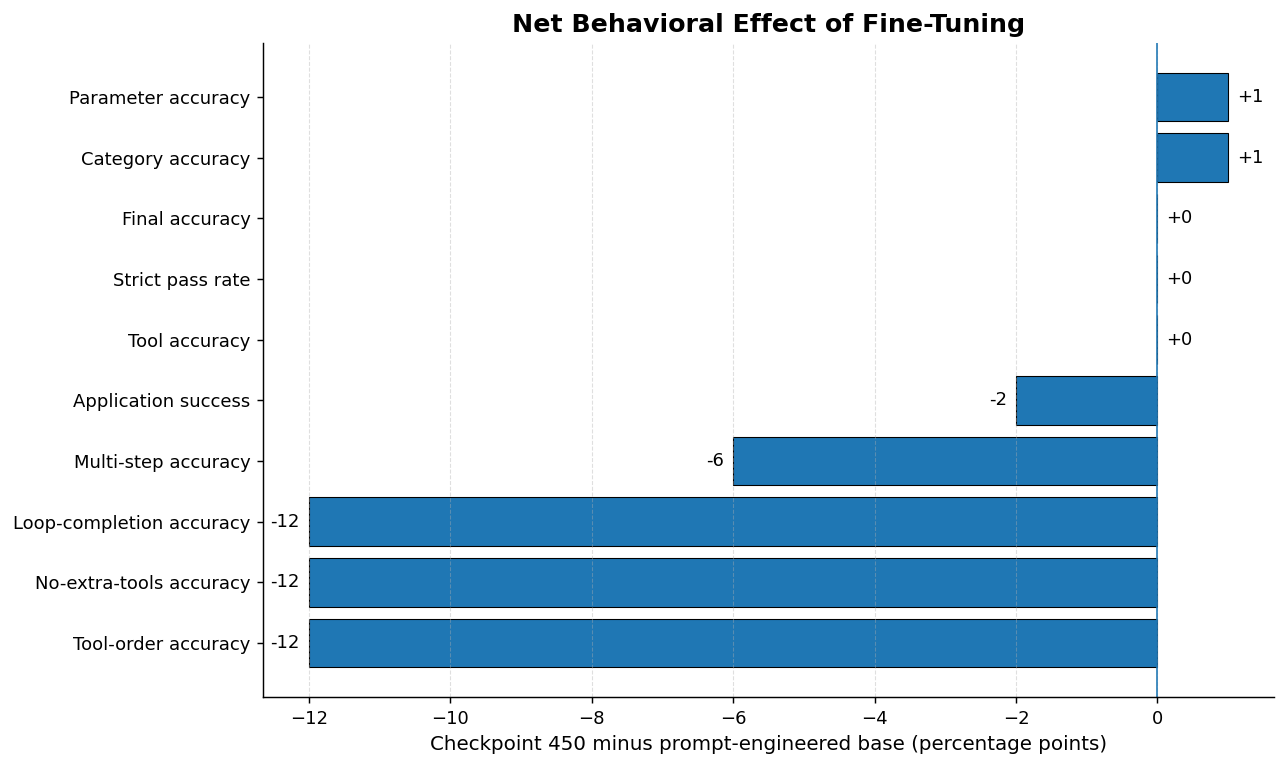

In [10]:
delta_plot = fine_tuning_delta.sort_values(
    "Change (points)"
)

fig, ax = plt.subplots(figsize=(10, 6))

bars = ax.barh(
    delta_plot["Metric"],
    delta_plot["Change (points)"],
    edgecolor="black",
    linewidth=0.6,
)

for bar in bars:
    value = bar.get_width()

    ax.annotate(
        f"{value:+.0f}",
        (
            value,
            bar.get_y() + bar.get_height() / 2,
        ),
        xytext=(5 if value >= 0 else -5, 0),
        textcoords="offset points",
        ha="left" if value >= 0 else "right",
        va="center",
    )

ax.axvline(0, linewidth=0.9)
ax.set_xlabel(
    "Checkpoint 450 minus prompt-engineered base "
    "(percentage points)"
)
ax.set_title("Net Behavioral Effect of Fine-Tuning")
ax.grid(
    axis="x",
    linestyle="--",
    linewidth=0.6,
    alpha=0.4,
)

plt.tight_layout()
plt.show()


**Figure 4 — Net effect of fine-tuning.** The adapter's positive effects are
small and localized, while its multi-step regressions are substantially larger.

This is the central result of the final notebook. A lower validation loss does
not automatically imply a better deployed agent.


## 8. Multi-Step Latency


In [11]:
latency_comparison = pd.DataFrame({
    "Configuration": [
        RAW_BASELINE["configuration"],
        PROMPT_ENGINEERED_BASE["configuration"],
        FINETUNED_V6_450["configuration"],
    ],
    "Average multi-step latency (s)": [
        RAW_BASELINE["multi_step"]["average_latency_seconds"],
        PROMPT_ENGINEERED_BASE["multi_step"]["average_latency_seconds"],
        FINETUNED_V6_450["multi_step"]["average_latency_seconds"],
    ],
})

display(latency_comparison.style.hide(axis="index"))


Configuration,Average multi-step latency (s)
Raw base model,3.000000
Prompt-engineered base,1.480000
Fine-tuned v6 — checkpoint 450,1.140000


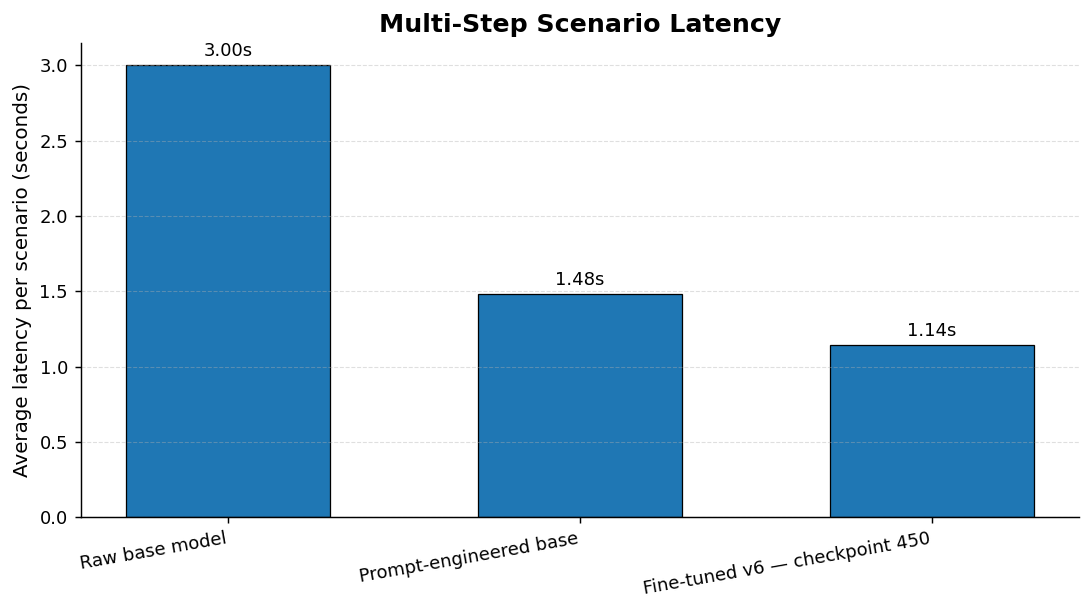

In [12]:
fig, ax = plt.subplots(figsize=(8.5, 4.8))

bars = ax.bar(
    latency_comparison["Configuration"],
    latency_comparison["Average multi-step latency (s)"],
    width=0.58,
    edgecolor="black",
    linewidth=0.7,
)

for bar in bars:
    ax.annotate(
        f"{bar.get_height():.2f}s",
        (
            bar.get_x() + bar.get_width() / 2,
            bar.get_height(),
        ),
        xytext=(0, 5),
        textcoords="offset points",
        ha="center",
    )

ax.set_ylabel("Average latency per scenario (seconds)")
ax.set_title("Multi-Step Scenario Latency")
ax.grid(
    axis="y",
    linestyle="--",
    linewidth=0.6,
    alpha=0.4,
)
plt.xticks(rotation=10, ha="right")

plt.tight_layout()
plt.show()


**Figure 5 — Multi-step latency.** Checkpoint 450 is faster than the
prompt-engineered base model:

- prompt-engineered base: 1.48 s;
- checkpoint 450: 1.14 s.

The latency gain does not compensate for the 12-point losses in tool ordering
and loop completion. Reliability remains the primary deployment criterion.


## 9. Production Decision Criteria


In [13]:
decision_table = pd.DataFrame({
    "Criterion": [
        "Strict single-step accuracy",
        "Application success",
        "Multi-step step accuracy",
        "Tool-order accuracy",
        "No-extra-tools accuracy",
        "Final-response accuracy",
        "Loop-completion accuracy",
        "Multi-step latency",
        "Additional adapter artifact",
    ],
    "Prompt-engineered base": [
        "89%",
        "91%",
        "98%",
        "98%",
        "98%",
        "98%",
        "98%",
        "1.48 s",
        "No",
    ],
    "Fine-tuned checkpoint 450": [
        "89%",
        "89%",
        "92%",
        "86%",
        "86%",
        "98%",
        "86%",
        "1.14 s",
        "Yes",
    ],
    "Preferred": [
        "Tie",
        "Prompt-engineered base",
        "Prompt-engineered base",
        "Prompt-engineered base",
        "Prompt-engineered base",
        "Tie",
        "Prompt-engineered base",
        "Fine-tuned checkpoint 450",
        "Prompt-engineered base",
    ],
})

display(decision_table.style.hide(axis="index"))


Criterion,Prompt-engineered base,Fine-tuned checkpoint 450,Preferred
Strict single-step accuracy,89%,89%,Tie
Application success,91%,89%,Prompt-engineered base
Multi-step step accuracy,98%,92%,Prompt-engineered base
Tool-order accuracy,98%,86%,Prompt-engineered base
No-extra-tools accuracy,98%,86%,Prompt-engineered base
Final-response accuracy,98%,98%,Tie
Loop-completion accuracy,98%,86%,Prompt-engineered base
Multi-step latency,1.48 s,1.14 s,Fine-tuned checkpoint 450
Additional adapter artifact,No,Yes,Prompt-engineered base


A weighted composite score is intentionally avoided. Arbitrary weights could
be adjusted until either model wins.

The deployment decision instead follows hard operational priorities:

1. strict correctness;
2. successful runtime behavior;
3. correct action order;
4. avoidance of unnecessary actions;
5. reliable loop completion;
6. latency only after correctness requirements are satisfied.


## 10. Final Deployment Decision

> **Caveat on this comparison.** The engineered prompt (Notebook 02) was
> iteratively revised against the same 320-example / 50-scenario benchmark
> used for the comparison below, while the fine-tuning corpus (Notebook 03)
> was verified to have zero overlap with it. This asymmetry favors the
> prompt-engineered baseline and should be kept in mind, especially for the
> metrics where the two configurations are close (e.g. strict single-step
> accuracy, tied at 89%).

### Recommended production baseline

Use the **base Qwen2.5-3B-Instruct model with the 2,469-token engineered system
prompt and runtime guardrails**.

This configuration:

- matches checkpoint 450 on strict single-step accuracy;
- exceeds it on application success;
- exceeds it by 6 points on multi-step step accuracy;
- exceeds it by 12 points on tool ordering;
- exceeds it by 12 points on avoiding extra tools;
- exceeds it by 12 points on loop completion;
- requires no LoRA adapter artifact.

### Role of checkpoint 450

Checkpoint 450 remains the retained fine-tuned research artifact because it is:

- the minimum-validation-loss checkpoint;
- the strongest multi-step checkpoint among 450, 650 and 850;
- evidence that LoRA can reinforce category and parameter decisions;
- useful for future dataset and ablation experiments.

It should not replace the prompt-engineered base model in production based on
the current clean benchmark.

### Required runtime safeguards

Regardless of the chosen model, AXION should retain:

- strict JSON-schema validation;
- category/tool registry validation;
- deterministic path normalization;
- rejection of repeated successful actions;
- action-order checks;
- loop-completion limits;
- structured logging of rejected calls.


## 11. Threats to Validity

This final comparison has several limitations:

1. **Single base model**  
   Results are specific to Qwen2.5-3B-Instruct.

2. **Single LoRA run**  
   `finetuning-v6` used seed 42. Multiple seeds are required to estimate
   training variance.

3. **Finite benchmark**  
   Exact normalized overlap is zero, but the benchmark remains one finite
   collection of templates and paraphrases.

4. **Incomplete metric parity**  
   Not every latency and memory field was available for the final checkpoint,
   so unsupported comparisons were omitted.

5. **Prompt and adapter interaction**  
   The fine-tuned model was evaluated as a complete prompted system. The
   adapter's isolated contribution is not measured independently.

6. **Rounded aggregate metrics**  
   Percentages are rounded. Exact pass counts should be archived with future
   benchmark releases.

7. **Benchmark-guided prompt development**  
   As noted in Notebook 02, the engineered prompt was tuned directly against
   the benchmark used throughout this comparison. The fine-tuned checkpoint
   was not. This is a structural advantage for the prompt-engineered baseline
   that is not corrected for anywhere in this notebook.

8. **Single-point learning-rate ablation**  
   Notebook 04, Section 11 shows that a 12x higher learning rate did not
   improve the fine-tuned checkpoint. This rules out an under-trained adapter
   as the explanation for the results below, but it is not an exhaustive
   sweep.


## 12. Final Project Summary


In [14]:
FINAL_SUMMARY = {
    "raw_strict_pass": "0%",
    "prompt_engineered_strict_pass": "89%",
    "fine_tuned_strict_pass": "89%",
    "prompt_engineered_application_success": "91%",
    "fine_tuned_application_success": "89%",
    "prompt_engineered_multi_step_accuracy": "98%",
    "fine_tuned_multi_step_accuracy": "92%",
    "prompt_engineered_tool_order": "98%",
    "fine_tuned_tool_order": "86%",
    "prompt_engineered_loop_completion": "98%",
    "fine_tuned_loop_completion": "86%",
    "selected_finetuned_checkpoint": "Iteration 450",
    "selected_validation_loss": "0.542",
    "train_benchmark_exact_overlap": "0 / 320",
    "recommended_deployment": (
        "Base Qwen2.5-3B-Instruct + 2,469-token engineered prompt "
        "+ runtime guardrails"
    ),
}

final_summary = pd.DataFrame({
    "Metric": [
        "Raw strict pass",
        "Prompt-engineered strict pass",
        "Fine-tuned strict pass",
        "Prompt-engineered application success",
        "Fine-tuned application success",
        "Prompt-engineered multi-step accuracy",
        "Fine-tuned multi-step accuracy",
        "Prompt-engineered tool order",
        "Fine-tuned tool order",
        "Prompt-engineered loop completion",
        "Fine-tuned loop completion",
        "Selected fine-tuned checkpoint",
        "Selected validation loss",
        "Train/benchmark exact overlap",
        "Recommended deployment",
    ],
    "Value": [
        FINAL_SUMMARY["raw_strict_pass"],
        FINAL_SUMMARY["prompt_engineered_strict_pass"],
        FINAL_SUMMARY["fine_tuned_strict_pass"],
        FINAL_SUMMARY["prompt_engineered_application_success"],
        FINAL_SUMMARY["fine_tuned_application_success"],
        FINAL_SUMMARY["prompt_engineered_multi_step_accuracy"],
        FINAL_SUMMARY["fine_tuned_multi_step_accuracy"],
        FINAL_SUMMARY["prompt_engineered_tool_order"],
        FINAL_SUMMARY["fine_tuned_tool_order"],
        FINAL_SUMMARY["prompt_engineered_loop_completion"],
        FINAL_SUMMARY["fine_tuned_loop_completion"],
        FINAL_SUMMARY["selected_finetuned_checkpoint"],
        FINAL_SUMMARY["selected_validation_loss"],
        FINAL_SUMMARY["train_benchmark_exact_overlap"],
        FINAL_SUMMARY["recommended_deployment"],
    ],
})

display(final_summary.style.hide(axis="index"))


Metric,Value
Raw strict pass,0%
Prompt-engineered strict pass,89%
Fine-tuned strict pass,89%
Prompt-engineered application success,91%
Fine-tuned application success,89%
Prompt-engineered multi-step accuracy,98%
Fine-tuned multi-step accuracy,92%
Prompt-engineered tool order,98%
Fine-tuned tool order,86%
Prompt-engineered loop completion,98%


## Conclusion

The AXION project demonstrates a clear experimental progression:

1. the raw model could not reliably follow the routing protocol;
2. prompt engineering converted it into a functional local agent;
3. dataset auditing removed structural defects and exact benchmark overlap;
4. LoRA fine-tuning produced a valid and reproducible adapter;
5. checkpoint analysis selected iteration 450 as the strongest fine-tuned
   candidate;
6. final evaluation showed that the adapter did not outperform prompt
   engineering alone as a complete agent.

The final evidence supports the following conclusion:

> Prompt engineering established AXION's routing behavior. Checkpoint 450
> slightly improved category and parameter prediction and reduced multi-step
> latency, but it degraded action ordering and loop completion. The
> prompt-engineered base model therefore remains the strongest overall
> production baseline on the clean benchmark.

This is not a failed project outcome. It is a defensible experimental result.
The work demonstrates dataset hygiene, reproducible training, checkpoint
selection and the ability to reject an initial hypothesis when the final
measurements do not support it -- including a dedicated learning-rate
ablation (Notebook 04, Section 11) that ruled out an under-trained adapter as
the cause, and an explicit acknowledgment that the prompt-engineered baseline
had a benchmark-tuning advantage the fine-tuned checkpoint did not.
